# California Housing

- **Problem Type**: Regression
- **Evaluation Metric**: RMSE
- **Models to test**:
  - Machine Learning
    - Linear Regression (Base Model - If other models can't beat this then it's useless to use anything else because of higher inference cost)
    - Decision Tree Regressor
    - Random Forest Regressor
    - Support Vector Regressor
    - KNearestNeighbour Regressor
  - Boosting
    - XGBoost Regressor
    - LightGBM Regressor
  - Deep Learning
    - Artificial Neural Network

## Brief Description of the dataset

This is the dataset used in the second chapter of Aurélien Géron's recent book 'Hands-On Machine learning with Scikit-Learn and TensorFlow'. It serves as an excellent introduction to implementing machine learning algorithms because it requires rudimentary data cleaning, has an easily understandable list of variables and sits at an optimal size between being to toyish and too cumbersome.

The data contains information from the 1990 California census. So although it may not help you with predicting current housing prices like the Zillow Zestimate dataset, it does provide an accessible introductory dataset for teaching people about the basics of machine learning.

## Loading Libraries

In [1]:
import os

os.environ["KERAS_BACKEND"] = "torch"

import time
import joblib

import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    FunctionTransformer
)

from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.metrics import *
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import mutual_info_regression

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
from keras import optimizers
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings

warnings.filterwarnings("ignore")

## Loading Dataset

In [2]:
df_og = pd.read_csv("data/housing.csv")
df_og.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Basic Information

In [3]:
df_og.shape

(20640, 10)

The dataset has 10 features and 20640 rows, totalling to 206400 data points.

In [4]:
df_og.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


1. longitude: A measure of how far west a house is; a higher value is farther west
2. latitude: A measure of how far north a house is; a higher value is farther north
3. housingMedianAge: Median age of a house within a block; a lower number is a newer building
4. totalRooms: Total number of rooms within a block
5. totalBedrooms: Total number of bedrooms within a block
6. population: Total number of people residing within a block
7. households: Total number of households, a group of people residing within a home unit, for a block
8. medianIncome: Median income for households within a block of houses (measured in tens of thousands of US Dollars)
9. medianHouseValue: Median house value for households within a block (measured in US Dollars)
10. oceanProximity: Location of the house w.r.t ocean/sea

Our dataset has 1 categorical and 9 numerical features, so we will do OneHotEncoding later in the pipeline

## Null Values Checking

In [5]:
df_og.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

We will handle this using Simple Imputer in the pipeline so that our information doesn't leak into the test dataset

## Statistics of our data

In [6]:
df_og.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


- `longitude` and `latitude` are location based values and location generally has very big impact on prices of data.
- `housing_median_age` seems to be the median age of all the houses in those longitude and latitude.
- 50% of the areas have 1447 to 3147 have `total_rooms`, which isn't very useful information so Engineering a `mean_total_rooms = total_rooms / households` would be a much better indicator for the pricing but we will check it during Mutual Information Regression.
- `total_bedrooms` feature is also similar to `total_rooms` so we can just do the same with it as well.
- 50% of the locations provided here has 280 to 605 `households`.
- 50% of the locations provided in the dataset has 787 to 1725 `population`.
- 50% of the location provided here have 25K to 47K `median_income`.
- `median_house_value` is our target feature which we need to predict which seems to be a bit skewed from its mean and 50th Quantile.

In [7]:
df_og[df_og.select_dtypes(["object"]).columns].describe(include="all")

,ocean_proximity
count,20640
unique,5
top,<1H OCEAN
freq,9136


This shows that most houses given here are less than just 1 hour away from ocean.

## Visuliation

In [8]:
def eda_plots(df, target=None):
    categorical_cols = df.select_dtypes(
        include=["object", "category", "bool"]
    ).columns.tolist()
    numerical_cols = df.select_dtypes(include="number").columns.tolist()

    if target:
        if target in categorical_cols:
            categorical_cols.remove(target)
            target_type = "categorical"
        elif target in numerical_cols:
            numerical_cols.remove(target)
            target_type = "numerical"
        else:
            raise ValueError(f"Target '{target}' not found in dataframe.")

    print("=" * 50)
    print("UNIVARIATE ANALYSIS")
    print("=" * 50)

    if numerical_cols:
        n_cols = 3
        n_rows = math.ceil(len(numerical_cols) / n_cols)
        fig, axes = plt.subplots(
            n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False
        )
        axes = axes.flatten()

        for i, col in enumerate(numerical_cols):
            sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
            axes[i].axvline(
                df[col].mean(), color="r", linestyle="dashed", linewidth=1.5
            )
            axes[i].set_title(f"Distribution: {col}")

        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()

    if numerical_cols:
        n_cols = 3
        n_rows = math.ceil(len(numerical_cols) / n_cols)
        fig, axes = plt.subplots(
            n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False
        )
        axes = axes.flatten()

        for i, col in enumerate(numerical_cols):
            axes[i].boxplot(df[col].dropna())
            axes[i].set_title(col)

        # Remove unused subplots
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()

    if categorical_cols:
        n_cols = 3
        n_rows = math.ceil(len(categorical_cols) / n_cols)
        fig, axes = plt.subplots(
            n_rows, n_cols, figsize=(15, 4 * n_rows), squeeze=False
        )
        axes = axes.flatten()

        for i, col in enumerate(categorical_cols):
            val_counts = df[col].value_counts()
            if len(val_counts) > 5:
                top = val_counts.head(5)
                top["Others"] = val_counts[5:].sum()
            else:
                top = val_counts

            axes[i].pie(top, labels=top.index, autopct="%1.1f%%", startangle=140)
            axes[i].set_title(f"Distribution: {col}")

        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()

    if target:
        print("\n" + "=" * 50)
        print("🔹 BIVARIATE ANALYSIS (Feature vs Target)")
        print("=" * 50)

        if numerical_cols:
            n_cols = 3
            n_rows = math.ceil(len(numerical_cols) / n_cols)
            fig, axes = plt.subplots(
                n_rows, n_cols, figsize=(15, 4 * n_rows), squeeze=False
            )
            axes = axes.flatten()

            for i, col in enumerate(numerical_cols):
                if target_type == "categorical":
                    sns.boxplot(data=df, x=target, y=col, ax=axes[i])
                else:
                    sns.scatterplot(data=df, x=col, y=target, alpha=0.5, ax=axes[i])
                axes[i].set_title(f"{col} vs {target}")

            for j in range(i + 1, len(axes)):
                fig.delaxes(axes[j])
            plt.tight_layout()
            plt.show()

        if categorical_cols:
            n_cols = 3
            n_rows = math.ceil(len(categorical_cols) / n_cols)
            fig, axes = plt.subplots(
                n_rows, n_cols, figsize=(15, 4 * n_rows), squeeze=False
            )
            axes = axes.flatten()

            for i, col in enumerate(categorical_cols):
                if target_type == "categorical":
                    sns.countplot(data=df, x=col, hue=target, ax=axes[i])
                else:
                    sns.boxplot(data=df, x=col, y=target, ax=axes[i])
                axes[i].tick_params(axis="x", rotation=45)
                axes[i].set_title(f"{col} vs {target}")

            for j in range(i + 1, len(axes)):
                fig.delaxes(axes[j])
            plt.tight_layout()
            plt.show()

    print("\n" + "=" * 50)
    print("🔹 MULTIVARIATE ANALYSIS")
    print("=" * 50)

    num_df = df.select_dtypes(include=["number"])
    if num_df.shape[1] > 1:
        plt.figure(figsize=(10, 8))
        corr = num_df.corr()
        sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
        plt.title("Correlation Heatmap")
        plt.show()

    sns.pairplot(df[numerical_cols].dropna(), corner=True)

    plt.suptitle(
        "Pairplot", y=1.02
    )
    plt.show()

UNIVARIATE ANALYSIS


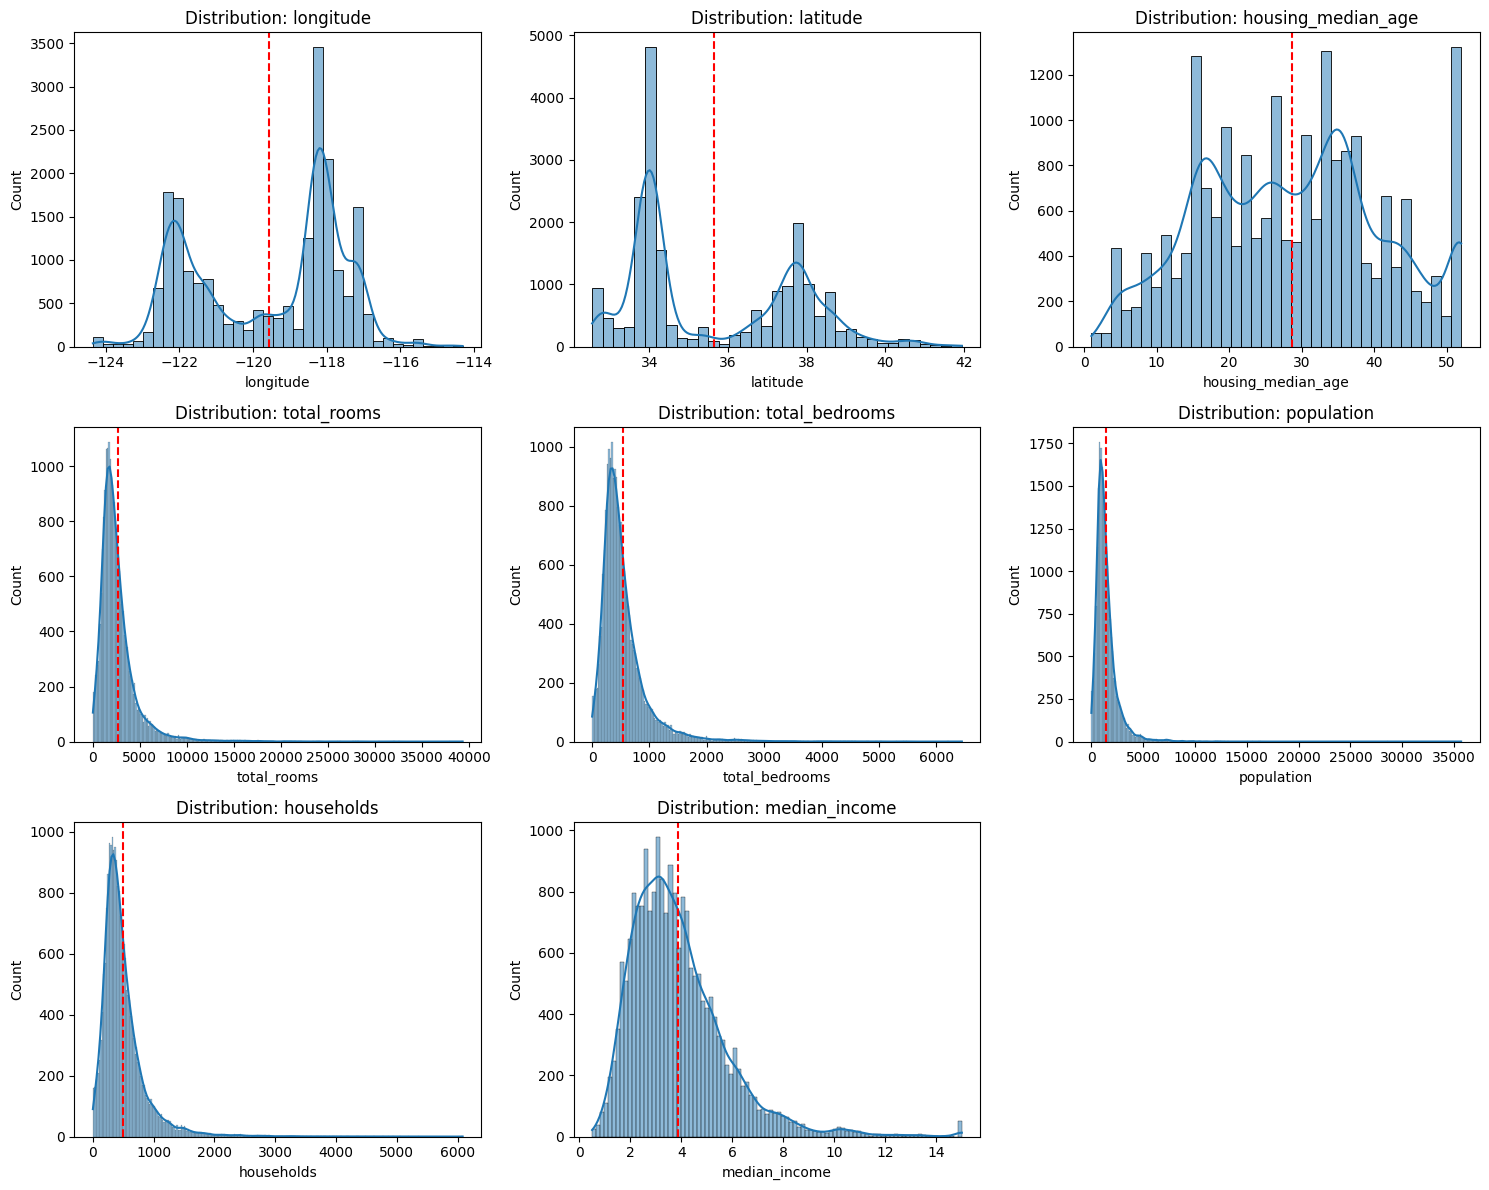

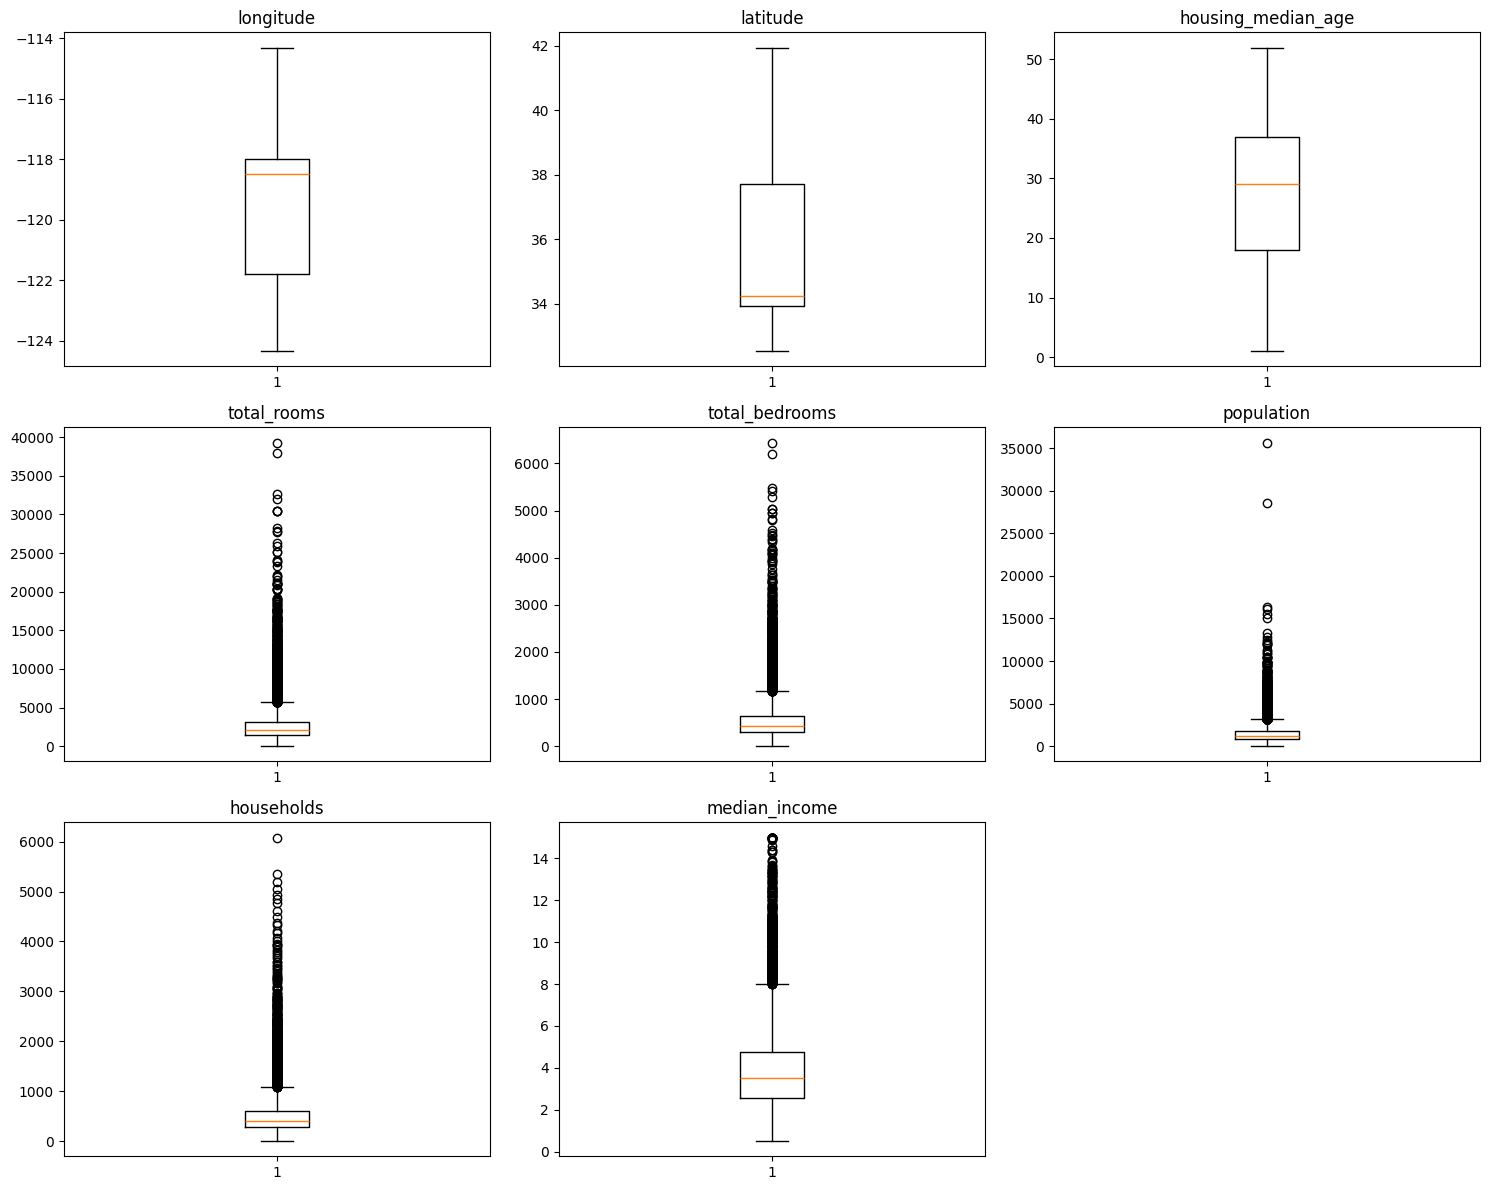

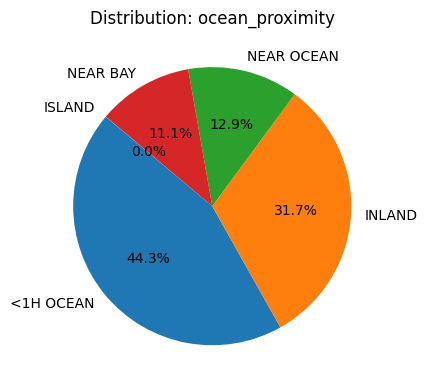


🔹 BIVARIATE ANALYSIS (Feature vs Target)


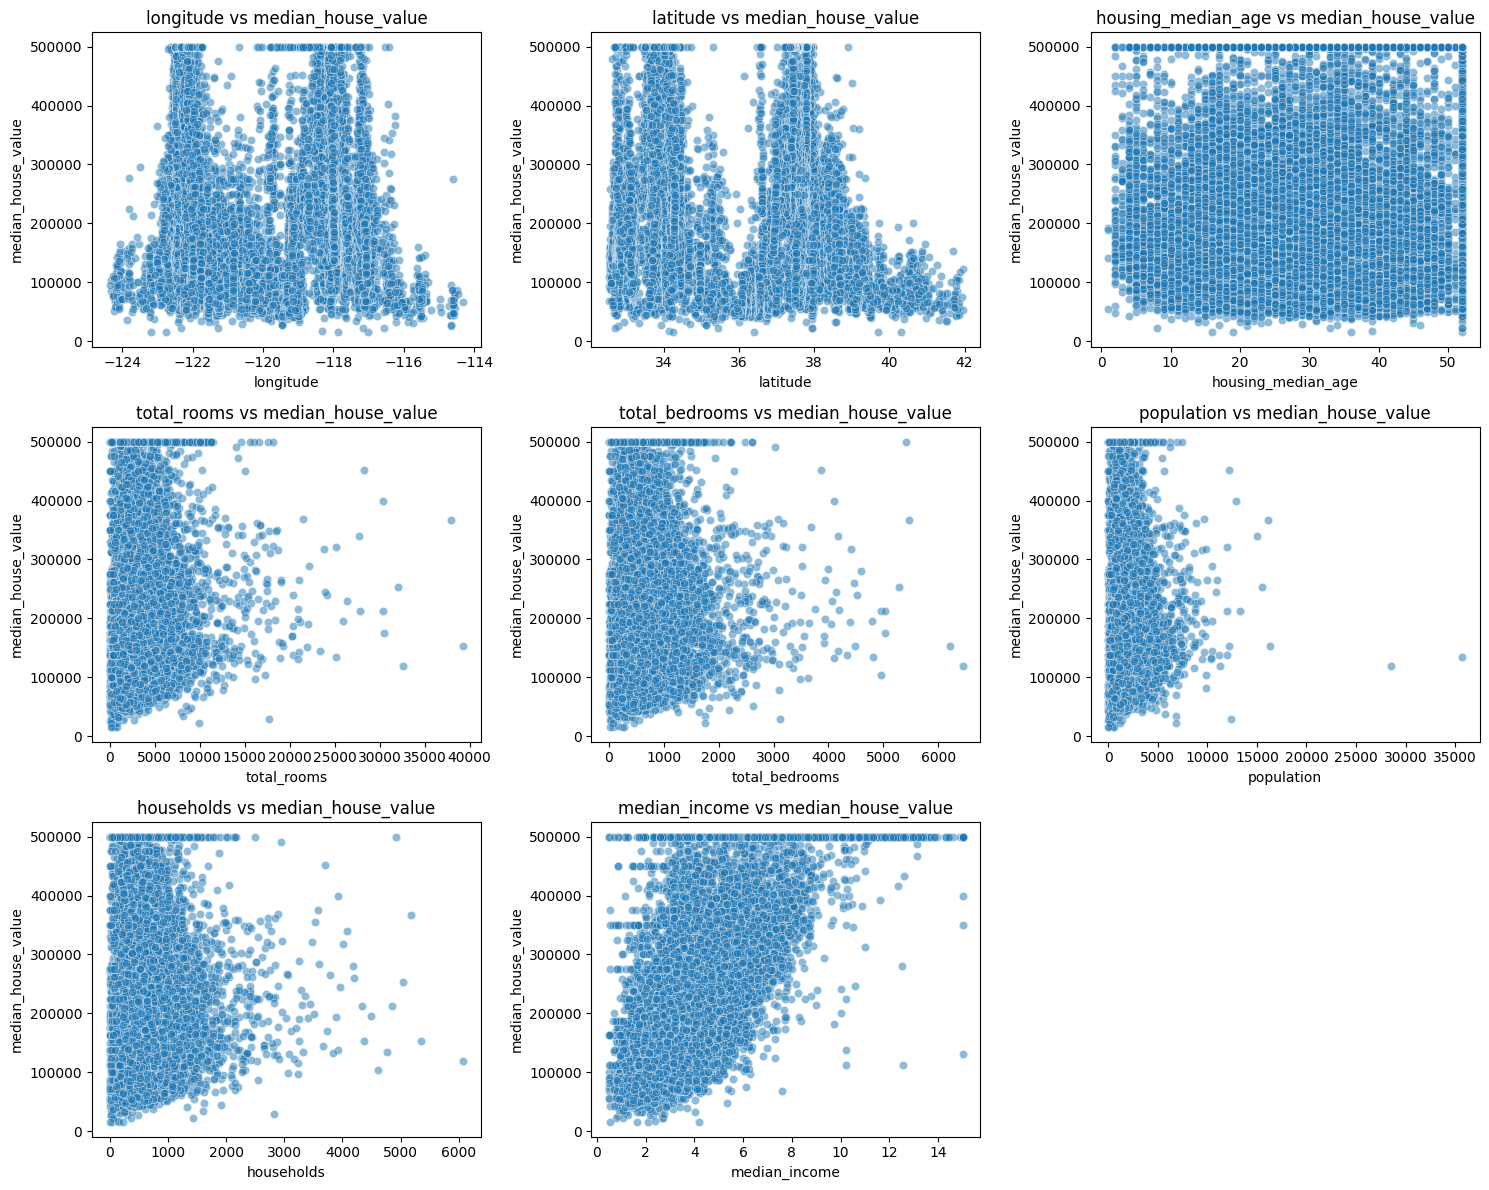

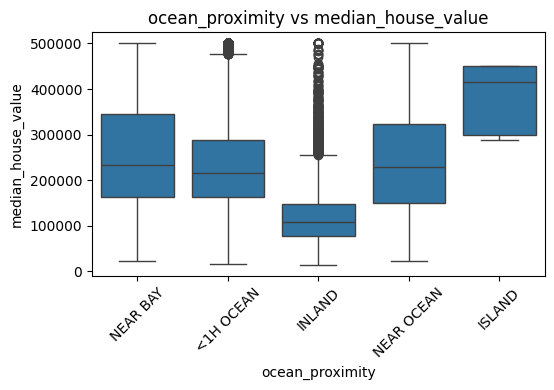


🔹 MULTIVARIATE ANALYSIS


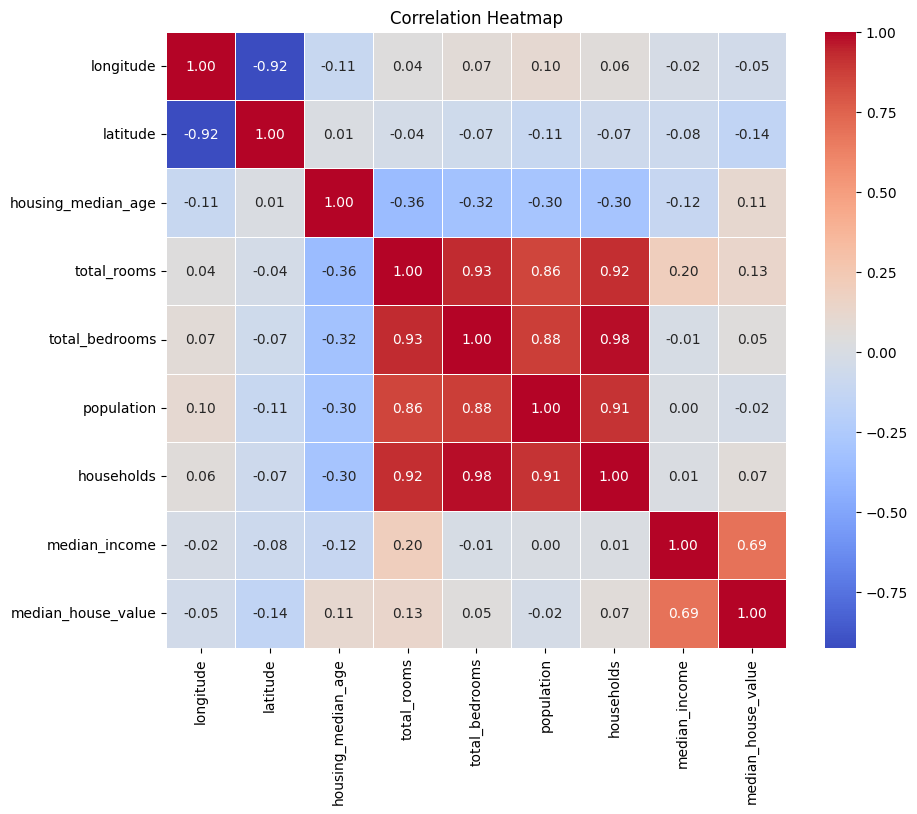

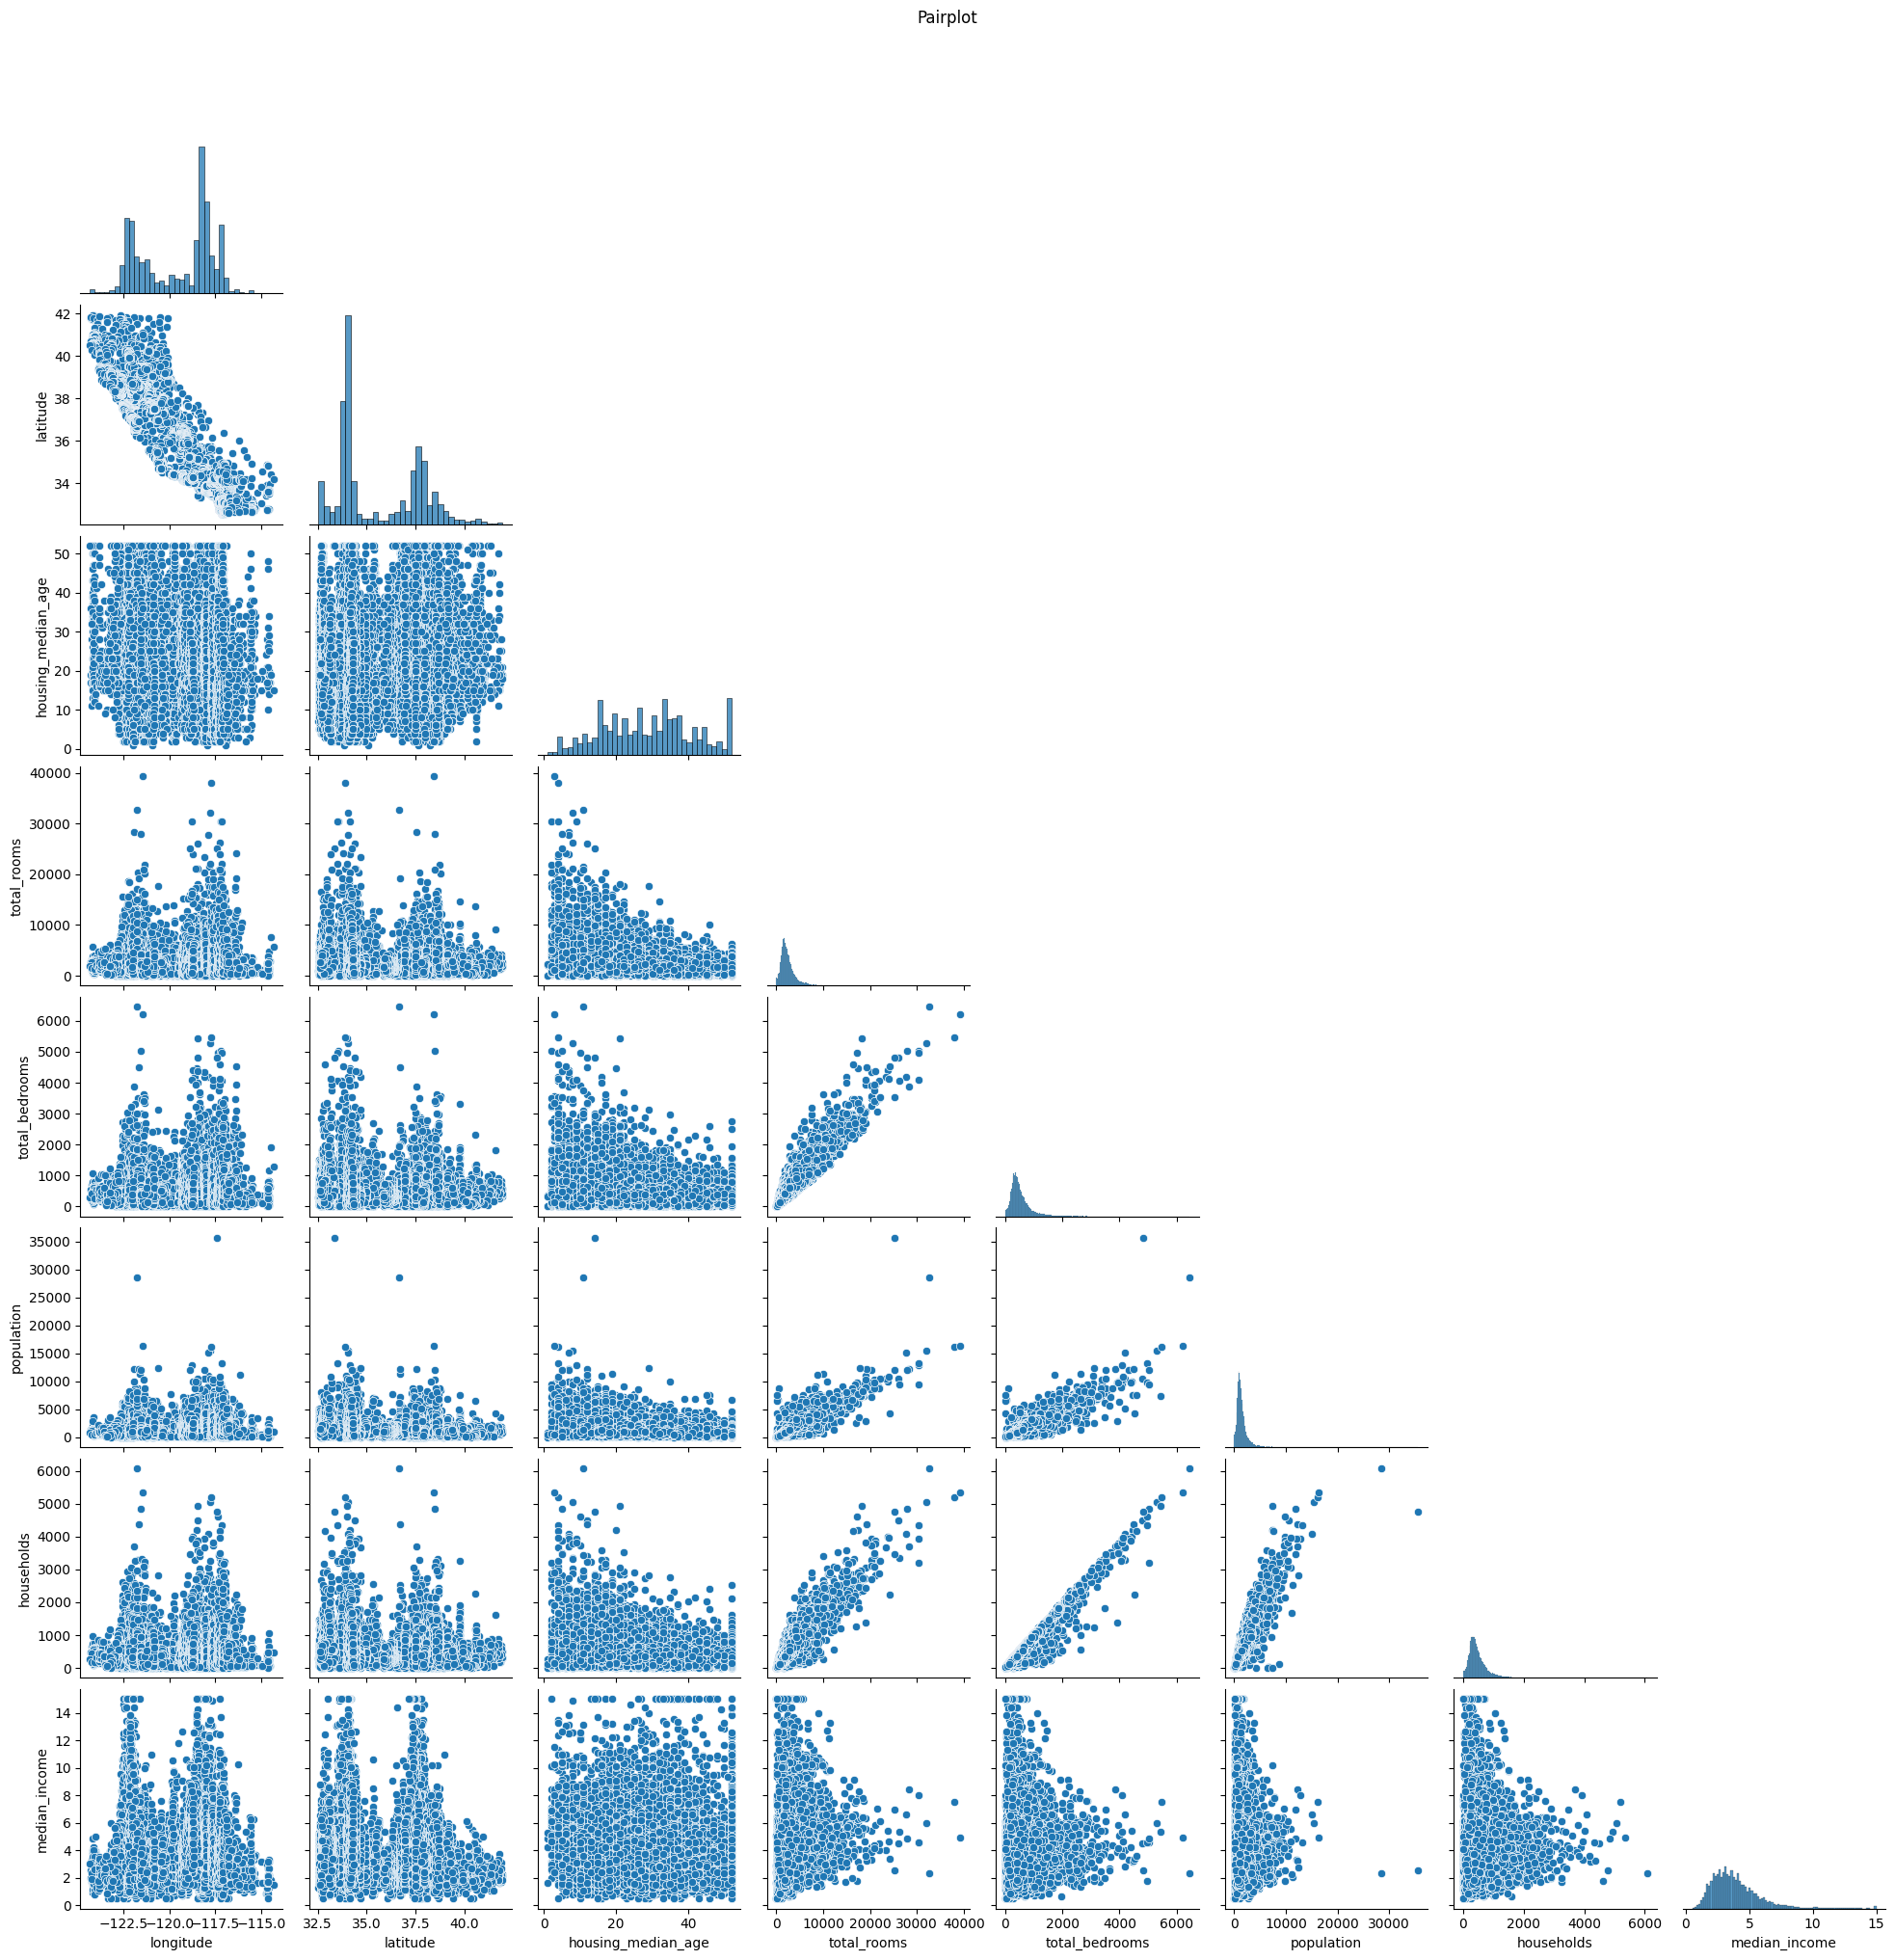

In [9]:
target = "median_house_value"
eda_plots(df_og, target)

### Conclusion

#### Univariate Analysis

1. Histplot
    - Numerical columns such as `total_rooms`, `total_bedrooms`, `population`, `households` are very right skewed.
    - And `median_income` while not as right skewed as other columns, is still right skewed.
2. Boxplot
    - Columns such as `total_rooms`, `total_bedrooms`, `population`, `households`, `median_income` has a lot of outliers but that's to be expected because the dataset contains middle class people to elite houses data.
3. Pie Chart
    - 44% of the houses are less than 1 hour away from ocean meaning a lot of the longitude and latitude given here are closer to ocean since california is also at the shore of ocean.
    - and only very few houses are on islands.

#### Bivariate Analysis

1. Scatterplot
    - Only `median_income` seems to be directly correlated with target.
    - Rest of the features don't seem to be have much correlation with target.

#### Multivariate Analysis

- `total_rooms`, `total_bedrooms`, `population`, `households` are highly correlated with each other which indicates very high multicollinearity and will result in large VIF later in feature selection

## Target Feature Analysis

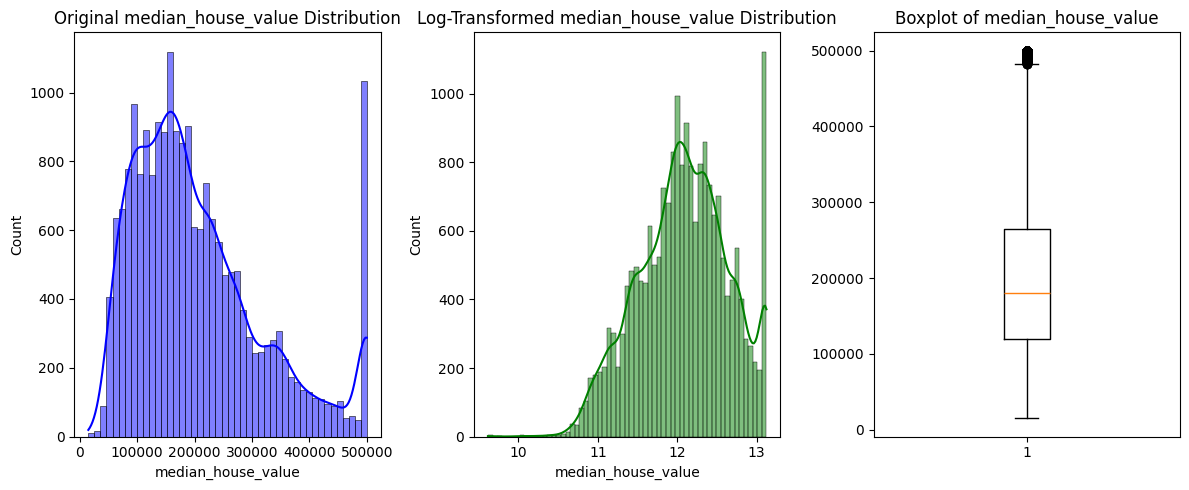

In [10]:
target = "median_house_value"

plt.figure(figsize=(12, 5))

# Plot 1: Standard Distribution
plt.subplot(1, 3, 1)
sns.histplot(df_og[target], kde=True, color="blue")
plt.title(f"Original {target} Distribution")

# Plot 2: Log Transformed Distribution
plt.subplot(1, 3, 2)
sns.histplot(np.log1p(df_og[target]), kde=True, color="green")
plt.title(f"Log-Transformed {target} Distribution")

# Plot 2: Boxplot
plt.subplot(1, 3, 3)
plt.boxplot(df_og[target])
plt.title(f"Boxplot of {target}")

plt.tight_layout()
plt.show()

Log transforming our target isn't a very feasible choice in this

## Feature Selection

In [11]:
df = df_og.copy(deep=True)

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [12]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object", "bool"]).columns
print(f"numerical cols: {numerical_cols}")
print(f"categorical cols: {categorical_cols}")

numerical cols: Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='str')
categorical cols: Index(['ocean_proximity'], dtype='str')


### VIF for numerical data

In [13]:
num_cols = df.select_dtypes(include="number").columns
X_num = df[num_cols].drop([target], axis=1)

# Create a temporary copy with no nulls
X_vif = X_num.fillna(X_num.median())

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))
]
print(vif_data.sort_values(by="VIF", ascending=False))

              Feature         VIF
0           longitude  614.390295
1            latitude  548.954416
6          households   73.547059
4      total_bedrooms   70.525566
3         total_rooms   29.032423
5          population   16.173089
7       median_income    8.003945
2  housing_median_age    7.281102


- While removing longitude and latitude because of High VIF seems logical, it is not a good practice because they are matematically tied to each other
- As expected, `total_rooms`, `total_bedrooms`, `population`, `households` have very high VIF

### Mutual Information Regression

In [14]:
# 1. Temporary Imputation
imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(imputer.fit_transform(X_num), columns=X_num.columns)

# 2. Add Engineered Features for comparison
X_imputed["rooms_per_household"] = X_imputed["total_rooms"] / X_imputed["households"]
X_imputed["bedrooms_per_room"] = X_imputed["total_bedrooms"] / X_imputed["total_rooms"]
X_imputed["pop_per_household"] = X_imputed["population"] / X_imputed["households"]

# 3. Calculate MIR
mi_scores = mutual_info_regression(X_imputed, df[target])
mi_results = pd.Series(mi_scores, name="MI Scores", index=X_imputed.columns)
print(mi_results.sort_values(ascending=False))

longitude              0.399315
median_income          0.387517
latitude               0.369354
bedrooms_per_room      0.137856
rooms_per_household    0.102893
pop_per_household      0.072948
total_rooms            0.041785
housing_median_age     0.034509
households             0.029293
total_bedrooms         0.025844
population             0.021254
Name: MI Scores, dtype: float64


This proves that our engineered features are much better than originals so we will just drop them

## Input - Target Split

In [15]:
X = df.drop(target, axis=1)
y = df[target]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (20640, 9)
y shape: (20640,)


## Train - Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train Shape: {X_train.shape}")
print(f"y_train Shape: {y_train.shape}")
print(f"X_test Shape: {X_test.shape}")
print(f"y_test Shape: {y_test.shape}")

X_train Shape: (16512, 9)
y_train Shape: (16512,)
X_test Shape: (4128, 9)
y_test Shape: (4128,)


## Preprocessors

In [17]:
def add_extra_features(X):
    # X is a numpy array from the pipeline
    # indices: 3:total_rooms, 4:total_bedrooms, 5:population, 6:households
    rooms_per_household = X[:, 3] / X[:, 6]
    bedrooms_per_room = X[:, 4] / X[:, 3]
    pop_per_household = X[:, 5] / X[:, 6]
    return np.c_[X, rooms_per_household, bedrooms_per_room, pop_per_household]

In [18]:
# 1. Define feature groups
num_cols = X.select_dtypes(include="number").columns
cat_cols = X.select_dtypes(include="object").columns


# ---------------------------------------------------------
# PIPELINE 1: For Linear/Distance Models (LogReg, SVM, KNN)
# Strategy: StandardScaler + OneHotEncoder
# ---------------------------------------------------------
linear_num_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("attribs_adder", FunctionTransformer(add_extra_features)),
        ("std_scaler", StandardScaler()),
    ]
)

linear_preprocessor = ColumnTransformer(
    [
        ("num", linear_num_pipeline, num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
    ]
)

# ---------------------------------------------------------
# PIPELINE 2: For Tree-Based Models (RF, XGB, LGBM, DT)
# Strategy: No Scaling (Passthrough) + OrdinalEncoder
# ---------------------------------------------------------
tree_num_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("attribs_adder", FunctionTransformer(add_extra_features)),
    ]
)

tree_preprocessor = ColumnTransformer(
    [
        ("num", tree_num_pipeline, num_cols),
        (
            "cat",
            OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
            cat_cols,
        ),
    ]
)

# ---------------------------------------------------------
# PIPELINE 3: For Neural Networks
# Strategy: MinMaxScaler + OneHotEncoder
# ---------------------------------------------------------
nn_num_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("attribs_adder", FunctionTransformer(add_extra_features)),
        ("scaler", MinMaxScaler()),
    ]
)

nn_preprocessor = ColumnTransformer(
    [
        ("num", nn_num_pipeline, num_cols),
        (
            "cat",
            OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"),
            cat_cols,
        ),
    ]
)

## Machine Learning

### Defining Pipelines

In [19]:
ml_models = {
    "Linear Regression": Pipeline(
        [("pre", linear_preprocessor), ("clf", LinearRegression())]
    ),
    "SVR": Pipeline([("pre", linear_preprocessor), ("clf", SVR())]),
    "KNN": Pipeline([("pre", linear_preprocessor), ("clf", KNeighborsRegressor())]),
    "Decision Tree": Pipeline(
        [("pre", tree_preprocessor), ("clf", DecisionTreeRegressor(random_state=42))]
    ),
    "Random Forest": Pipeline(
        [("pre", tree_preprocessor), ("clf", RandomForestRegressor(random_state=42))]
    ),
    "XGBoost": Pipeline(
        [("pre", tree_preprocessor), ("clf", XGBRegressor(device="cuda", random_state=42))]
    ),
    "LightGBM": Pipeline(
        [
            ("pre", tree_preprocessor),
            ("clf", LGBMRegressor(verbose=-1, random_state=42)),
        ]
    ),
}

### Training the Pipelines

In [20]:
results_list = []

for name, model in ml_models.items():
    # Train the model on the log-transformed data
    model.fit(X_train, y_train)

    # Model outputs predictions in log scale
    y_pred = model.predict(X_test)

    # Calculate metrics on the actual dollar amounts
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results_list.append({"Model": name, "RMSE": rmse, "R2": r2})
    print(f"Training done for {name}")

ML_Results = pd.DataFrame(results_list).sort_values(by="R2", ascending=False)
display(ML_Results)

Training done for Linear Regression
Training done for SVR
Training done for KNN
Training done for Decision Tree
Training done for Random Forest
Training done for XGBoost
Training done for LightGBM


,Model,RMSE,R2
6,LightGBM,46323.643010,0.836243
5,XGBoost,48111.219669,0.823361
4,Random Forest,50519.296473,0.805236
2,KNN,62186.751694,0.704887
0,Linear Regression,72701.326008,0.596654
3,Decision Tree,72902.215611,0.594422
1,SVR,116929.568231,-0.043378


LightBGM performs the Best here, so Hyperparamter tuning on it, because if Neural Network can't beat the very best of ML Model then it is useless due to higher inference cost

### Hyperparameter Tuning

In [21]:
param_dist = {
    "clf__n_estimators": [100, 500, 1000],
    "clf__learning_rate": [0.01, 0.05, 0.1],
    "clf__num_leaves": [20, 31, 50, 100],
    "clf__max_depth": [-1, 10, 20],
    "clf__subsample": [0.7, 0.8, 0.9],
    "clf__colsample_bytree": [0.7, 0.8, 0.9],
}

lgbm_search = RandomizedSearchCV(
    ml_models["LightGBM"],
    param_distributions=param_dist,
    n_iter=50,
    cv=3,
    scoring="neg_root_mean_squared_error",
    verbose=1,
    random_state=42,
    n_jobs=-1,
)

lgbm_search.fit(X_train, y_train)

print(f"\nBest Parameters: {lgbm_search.best_params_}")

best_lgbm = lgbm_search.best_estimator_
best_lgbm

Fitting 3 folds for each of 50 candidates, totalling 150 fits

Best Parameters: {'clf__subsample': 0.7, 'clf__num_leaves': 31, 'clf__n_estimators': 1000, 'clf__max_depth': 20, 'clf__learning_rate': 0.05, 'clf__colsample_bytree': 0.9}


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spar

In [22]:
y_pred = best_lgbm.predict(X_test)

r2_xgb = r2_score(y_test, y_pred)

rmse_xgb = root_mean_squared_error(y_test, y_pred)

print("=" * 40)
print(f"Best LightGBM pipeline Score")
print(f"R2 Score: {r2_xgb}")
print(f"RMSE    : {rmse_xgb}")
print("=" * 40)

Best LightGBM pipeline Score
R2 Score: 0.8553583704056553
RMSE    : 43536.15624372734


Our Hyperparameter tuned LightGBM has 0.85 R2 and 45K RMSE which is much better than before, so we can now compare it against the best ANN with its best optimiser, learning_rate and batch_size

## Artificial Neural Network

In [23]:
X_train_nn = nn_preprocessor.fit_transform(X_train)
X_test_nn = nn_preprocessor.transform(X_test)

input_shape = X_train_nn.shape[1]
print(f"input_shape: {input_shape}")

input_shape: 15


In [24]:
# Setup
y_train_arr = np.array(y_train)
input_shape = X_train_nn.shape[1]

optimizers_list = ["Adam", "RMSprop"]
learning_rates = [0.1, 0.05, 0.01]
batch_sizes = [32, 64, 128]

# Standard KFold for continuous target
kfold = KFold(n_splits=3, shuffle=True, random_state=42)

# Model
def build_model(input_shape, optimizer_name, lr):
    keras.backend.clear_session()

    model = Sequential(
        [
            Dense(
                128,
                activation="relu",
                kernel_initializer="he_normal",
                input_shape=(input_shape,),
            ),
            BatchNormalization(),
            Dropout(0.2),

            Dense(128, activation="relu", kernel_initializer="he_normal"),
            BatchNormalization(),
            Dropout(0.2),

            Dense(64, activation="relu", kernel_initializer="he_normal"),
            BatchNormalization(),

            Dense(32, activation="relu", kernel_initializer="he_normal"),

            Dense(1, activation="linear"),
        ]
    )

    if optimizer_name == "Adam":
        opt = optimizers.Adam(learning_rate=lr)
    else:
        opt = optimizers.RMSprop(learning_rate=lr)

    model.compile(
        loss="mean_squared_error",
        optimizer=opt,
    )
    return model


# Training Loop
cv_results_list = []
print("Starting 3-Fold CV Search for Regression...")
print("-" * 65)

for opt_name in optimizers_list:
    for lr in learning_rates:
        for batch in batch_sizes:
            fold_rmses = []
            config_name = f"{opt_name}_LR{lr}_BS{batch}"

            start_time = time.perf_counter()

            for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(X_train_nn)):
                X_fold_train, X_fold_val = X_train_nn[train_idx], X_train_nn[val_idx]
                y_fold_train, y_fold_val = y_train_arr[train_idx], y_train_arr[val_idx]

                model = build_model(input_shape, opt_name, lr)

                es = EarlyStopping(
                    monitor="val_loss", patience=12, restore_best_weights=True
                )
                rlr = ReduceLROnPlateau(
                    monitor="val_loss", factor=0.5, patience=6, min_lr=1e-6
                )

                model.fit(
                    X_fold_train,
                    y_fold_train,
                    epochs=60,
                    batch_size=batch,
                    validation_data=(X_fold_val, y_fold_val),
                    callbacks=[es, rlr],
                    verbose=0,
                )

                # Predict in log scale
                y_pred = model.predict(X_fold_val, verbose=0).flatten()

                # Calculate real-dollar RMSE
                fold_rmse = root_mean_squared_error(y_fold_val, y_pred)
                fold_rmses.append(fold_rmse)

            end_time = time.perf_counter()
            elapsed_time = end_time - start_time

            mean_rmse = np.mean(fold_rmses)
            std_rmse = np.std(fold_rmses)

            print(
                f"Config: {config_name:25} | Mean RMSE: ${mean_rmse:,.0f} | StD: ${std_rmse:,.0f} | Time Taken: {elapsed_time:.2f}"
            )

            cv_results_list.append(
                {
                    "Optimizer": opt_name,
                    "LR": lr,
                    "BS": batch,
                    "Mean RMSE": mean_rmse,
                    "StD": std_rmse,
                }
            )

CV_Results = pd.DataFrame(cv_results_list).sort_values(by="Mean RMSE", ascending=True)
print("\n" + "=" * 40)
print("TOP 5 ROBUST CONFIGURATIONS")
print("=" * 40)
display(CV_Results.head(5))

Starting 3-Fold CV Search for Regression...
-----------------------------------------------------------------
Config: Adam_LR0.1_BS32           | Mean RMSE: $56,685 | StD: $1,774 | Time Taken: 433.82
Config: Adam_LR0.1_BS64           | Mean RMSE: $57,864 | StD: $4,682 | Time Taken: 189.80
Config: Adam_LR0.1_BS128          | Mean RMSE: $54,349 | StD: $788 | Time Taken: 129.71
Config: Adam_LR0.05_BS32          | Mean RMSE: $58,548 | StD: $1,870 | Time Taken: 334.52
Config: Adam_LR0.05_BS64          | Mean RMSE: $55,513 | StD: $555 | Time Taken: 228.54
Config: Adam_LR0.05_BS128         | Mean RMSE: $55,147 | StD: $395 | Time Taken: 128.02
Config: Adam_LR0.01_BS32          | Mean RMSE: $56,224 | StD: $1,004 | Time Taken: 457.57
Config: Adam_LR0.01_BS64          | Mean RMSE: $56,034 | StD: $594 | Time Taken: 230.52
Config: Adam_LR0.01_BS128         | Mean RMSE: $54,507 | StD: $1,106 | Time Taken: 128.43
Config: RMSprop_LR0.1_BS32        | Mean RMSE: $60,010 | StD: $1,589 | Time Taken: 241.9

,Optimizer,LR,BS,Mean RMSE,StD
2,Adam,0.10,128,54348.794625,788.208380
17,RMSprop,0.01,128,54475.413969,1558.340667
8,Adam,0.01,128,54506.520547,1106.053640
16,RMSprop,0.01,64,54631.915553,1059.884042
14,RMSprop,0.05,128,55117.089805,1103.893829


This means the best configuration for this project is
- **Optimiser**: Adam
- **Learning Rate**: 0.01
- **Batch Size**: 128


Training Final Model with Adam, LR: 0.1, Batch: 128...
Epoch 1/150
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 21054535680.0000 - val_loss: 61598609408.0000 - learning_rate: 0.1000
Epoch 2/150
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5102447616.0000 - val_loss: 15600375808.0000 - learning_rate: 0.1000
Epoch 3/150
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4468676096.0000 - val_loss: 5682186752.0000 - learning_rate: 0.1000
Epoch 4/150
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4242773504.0000 - val_loss: 4892670464.0000 - learning_rate: 0.1000
Epoch 5/150
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4311303168.0000 - val_loss: 7869757952.0000 - learning_rate: 0.1000
Epoch 6/150
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4033291264.0000 - val_loss: 4300102656.0000 - learning_rate: 0.1000
Epoch 7/150
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3916539136.0000 - val_loss: 5582375936.0000 - learning_rate: 0.1000
Epoch 8/150
104/104 ━━━━━━━━━━━━━━━━━━

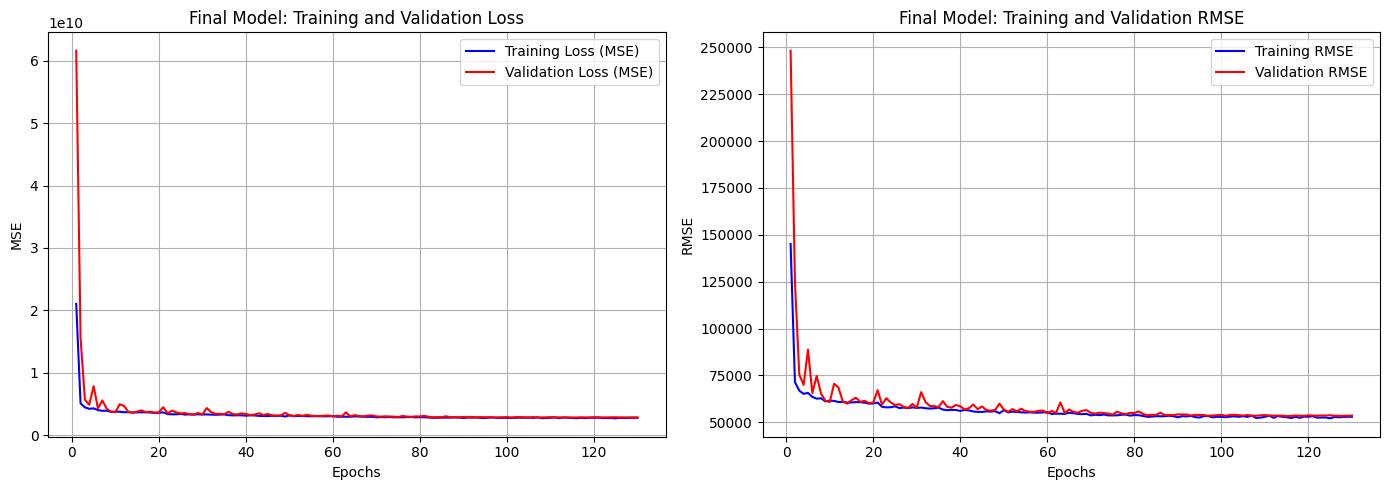

In [25]:
best_opt = CV_Results.iloc[0]["Optimizer"]
best_lr = CV_Results.iloc[0]["LR"]
best_bs = CV_Results.iloc[0]["BS"]

print(f"\nTraining Final Model with {best_opt}, LR: {best_lr}, Batch: {best_bs}...")

keras.backend.clear_session()
final_model = build_model(input_shape, best_opt, best_lr)

final_callbacks = [
    EarlyStopping(
        monitor="val_loss", patience=15, restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=7, min_lr=1e-7, verbose=1
    ),
]

final_history = final_model.fit(
    X_train_nn,
    y_train_arr,
    validation_split=0.2,
    epochs=150,
    batch_size=int(best_bs),
    callbacks=final_callbacks,
    verbose=1,
)


def plot_final_performance(history):
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    # Calculate log-scale RMSE directly from the MSE loss
    rmse = np.sqrt(loss)
    val_rmse = np.sqrt(val_loss)

    epochs = range(1, len(loss) + 1)

    plt.figure(figsize=(14, 5))

    # Loss Plot (MSE)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, "b", label="Training Loss (MSE)")
    plt.plot(epochs, val_loss, "r", label="Validation Loss (MSE)")
    plt.title("Final Model: Training and Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("MSE")
    plt.legend()
    plt.grid(True)

    # RMSE Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, rmse, "b", label="Training RMSE")
    plt.plot(epochs, val_rmse, "r", label="Validation RMSE")
    plt.title("Final Model: Training and Validation RMSE")
    plt.xlabel("Epochs")
    plt.ylabel("RMSE")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


plot_final_performance(final_history)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

--- Final Production Regression Metrics ---
Neural Network RMSE: 54751.6901
Neural Network R2:   0.7712


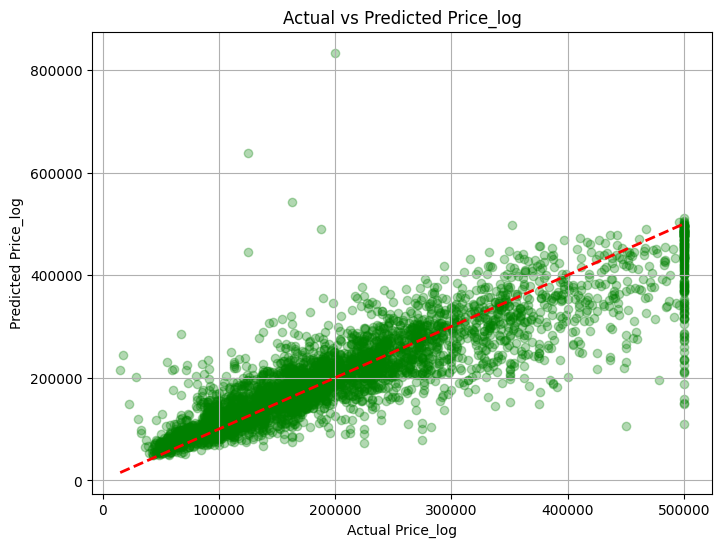

In [26]:
y_pred_nn = final_model.predict(X_test_nn).flatten()

final_rmse = root_mean_squared_error(y_test, y_pred_nn)
final_r2 = r2_score(y_test, y_pred_nn)

print("\n--- Final Production Regression Metrics ---")
print(f"Neural Network RMSE: {final_rmse:.4f}")
print(f"Neural Network R2:   {final_r2:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_nn, alpha=0.3, color="green")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    lw=2,
)
plt.title("Actual vs Predicted Price_log")
plt.xlabel("Actual Price_log")
plt.ylabel("Predicted Price_log")
plt.grid(True)
plt.show()

Our best neural network could capture 77% of the variance as seen from R2 score and has an RMSE of 54K Dollars.

## Models Comparison

In [27]:
nn_pred = final_model.predict(X_test_nn, verbose=0).flatten()

xgb_pred = ml_models["XGBoost"].predict(X_test)

lgbm_pred = best_lgbm.predict(X_test)

final_results = [
    {
        "Model": "Tuned LightGBM",
        "RMSE ($)": root_mean_squared_error(y_test, lgbm_pred),
        "R2 Score": r2_score(y_test, lgbm_pred),
    },
    {
        "Model": "Baseline XGBoost",
        "RMSE ($)": root_mean_squared_error(y_test, xgb_pred),
        "R2 Score": r2_score(y_test, xgb_pred),
    },
    {
        "Model": "Deep Neural Network",
        "RMSE ($)": root_mean_squared_error(y_test, nn_pred),
        "R2 Score": r2_score(y_test, nn_pred),
    },
]

Final_Leaderboard = pd.DataFrame(final_results).sort_values(
    by="RMSE ($)", ascending=True
)

print("=" * 50)
print("FINAL TEST SET LEADERBOARD")
print("=" * 50)
display(Final_Leaderboard)

FINAL TEST SET LEADERBOARD


,Model,RMSE ($),R2 Score
0,Tuned LightGBM,43536.156244,0.855358
1,Baseline XGBoost,48111.219669,0.823361
2,Deep Neural Network,54751.690115,0.771236


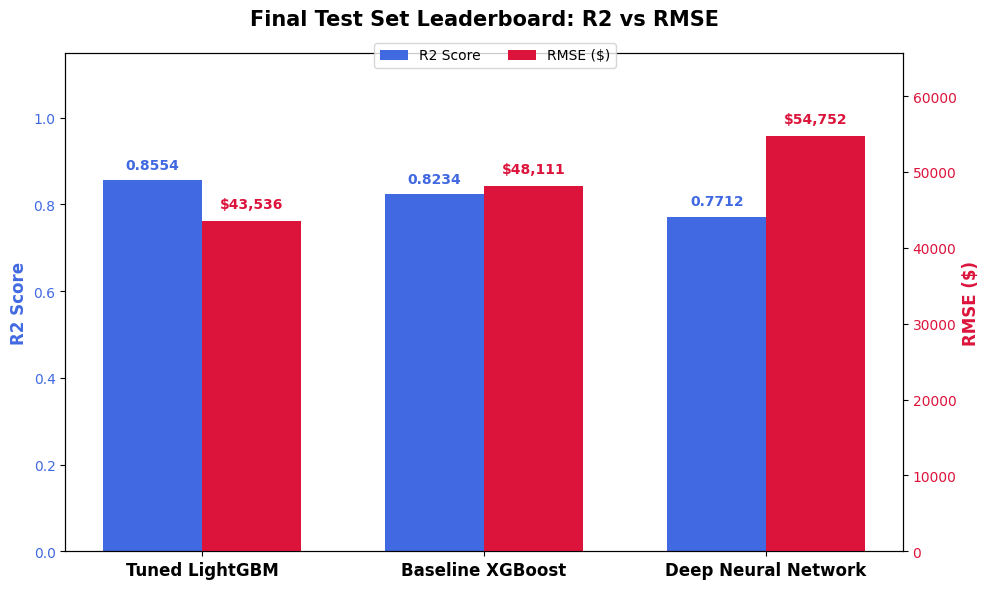

In [28]:
fig, ax1 = plt.subplots(figsize=(10, 6))
x = np.arange(len(Final_Leaderboard["Model"]))
width = 0.35

bars1 = ax1.bar(
    x - width / 2,
    Final_Leaderboard["R2 Score"],
    width,
    label="R2 Score",
    color="royalblue",
)
ax1.set_ylabel("R2 Score", color="royalblue", fontsize=12, fontweight="bold")
ax1.tick_params(axis="y", labelcolor="royalblue")
ax1.set_ylim(0, 1.15)  # Extra headroom for annotations

ax1.set_xticks(x)
ax1.set_xticklabels(Final_Leaderboard["Model"], fontsize=12, fontweight="bold")

ax2 = ax1.twinx()
bars2 = ax2.bar(
    x + width / 2,
    Final_Leaderboard["RMSE ($)"],
    width,
    label="RMSE ($)",
    color="crimson",
)
ax2.set_ylabel("RMSE ($)", color="crimson", fontsize=12, fontweight="bold")
ax2.tick_params(axis="y", labelcolor="crimson")
ax2.set_ylim(0, Final_Leaderboard["RMSE ($)"].max() * 1.2)

for bar in bars1:
    yval = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 0.02,
        f"{yval:.4f}",
        ha="center",
        va="bottom",
        color="royalblue",
        fontweight="bold",
        fontsize=10,
    )

for bar in bars2:
    yval = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        yval + (ax2.get_ylim()[1] * 0.02),
        f"${yval:,.0f}",
        ha="center",
        va="bottom",
        color="crimson",
        fontweight="bold",
        fontsize=10,
    )

plt.title(
    "Final Test Set Leaderboard: R2 vs RMSE", fontsize=15, pad=20, fontweight="bold"
)
fig.legend(loc="upper center", bbox_to_anchor=(0.5, 0.93), ncol=2, frameon=True)

plt.tight_layout()
plt.show()

Our best Neural Network didn't even come close to the performance of Baseline LightGBM let alone Tuned XGBoost

# Conclusion

- LightGBM is the best model here with
  - **R2 Score**: 85%
  - **RMSE**    : 43,536 $

- **Why did traditional ML Outperforme ANN here:**
  - ANN are data hungry and lazy learner.
  - ANNs starts with completely randomised weights and slowly learn pattern via feeding them lots of data.
  - But here we only had very small data.
  - The ANN didn't have enough data to learn the patterns here.
  - Whereas Traditional ML doesn't require that much data.
  - if given enough data, ANN wouldv'e surpassed Tuned LightGBM easily but that isn't the case here.